In [7]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [2]:
def build_wave_presence_table(trial_info_csv, events_csv, day):
    """
    Create a table of all trials from a given day with their trial type and
    whether a wave was detected in each stage ('pre', 'stim', 'post').

    Parameters
    ----------
    trial_info_csv : str
        Path to the trial_info CSV (contains 'Date', 'TrialID', 'TrialType', ...).
    events_csv : str
        Path to the events_df CSV (contains 'trial_id', 'stage', ...).
    day : str
        Date string matching the 'Date' column in trial_info (e.g., "2025-07-15").

    Returns
    -------
    pandas.DataFrame
        Columns: ['TrialID', 'TrialType', 'pre', 'stim', 'post'] with booleans.
    """
    # Load data
    trial_info = pd.read_csv(trial_info_csv)
    events = pd.read_csv(events_csv)

    # Clean up TrialIDs (remove 'Visual/' prefix if present)
    trial_info["TrialID"] = trial_info["TrialID"].str.replace("^Visual/", "", regex=True)

    # Filter trials for the given day
    day_trials = (
        trial_info.loc[trial_info["Date"] == day, ["TrialID", "TrialType"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    # Keep only events from today's trials
    events_day = events[events["trial_id"].isin(day_trials["TrialID"])]

    # Check which stages have waves per trial
    stage_presence = (
        events_day[["trial_id", "stage"]]
        .drop_duplicates()
        .assign(value=True)
        .pivot_table(index="trial_id", columns="stage", values="value", aggfunc="any", fill_value=False)
        .reindex(columns=["pre", "stim", "post"], fill_value=False)
        .reset_index()
        .rename(columns={"trial_id": "TrialID"})
    )

    # Merge with trials list (include all trials even if no wave detected)
    result = (
        day_trials.merge(stage_presence, on="TrialID", how="left")
        .fillna({"pre": False, "stim": False, "post": False})
        .loc[:, ["TrialID", "TrialType", "pre", "stim", "post"]]
        .sort_values("TrialID")
        .reset_index(drop=True)
    )

    return result

In [3]:
wave_df = build_wave_presence_table('C:/Users/Katie/Documents/Katie/Code/perception_project/perception_project/trial_info/TrialInfo_cfm002mjr.csv', 
                                    'events_df_cfm002_240517.csv', 240517)

C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\1857750554.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna({"pre": False, "stim": False, "post": False})


In [4]:
display(wave_df)

,TrialID,TrialType,pre,stim,post
0,cfm002mjr/20240517/meas00/trial001,HC Hit (3),True,True,True
1,cfm002mjr/20240517/meas00/trial002,Correct Rejection (4),True,True,True
2,cfm002mjr/20240517/meas00/trial003,MC Hit (2),True,True,True
3,cfm002mjr/20240517/meas00/trial004,MC Miss (5),True,True,True
4,cfm002mjr/20240517/meas00/trial005,HC Hit (3),True,True,True
...,...,...,...,...,...
265,cfm002mjr/20240517/meas02/trial095,LC No Report (7),False,False,False
266,cfm002mjr/20240517/meas02/trial096,HC No Report (9),False,False,False
267,cfm002mjr/20240517/meas02/trial097,MC No Report (8),False,False,False
268,cfm002mjr/20240517/meas02/trial098,HC No Report (9),False,False,False


In [5]:
events = pd.read_csv('events_df_cfm002_240517.csv')


Filtered events:
trial_type
HC No Report (9)    247
MC Miss (5)         128
HC Hit (3)           82
MC Hit (2)           22
Name: count, dtype: int64

By stage:
stage
pre     236
stim    123
post    120
Name: count, dtype: int64

Summary statistics (per trial_type x stage):


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\1449223226.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])


,trial_type,stage,n_events,R_mean,R_median,R_std,freq_mean,freq_median,freq_std,lam_mean,lam_median,lam_std
0,HC Hit (3),pre,39,0.603128,0.630208,0.186043,4.748467,4.277118,2.080524,88.938854,77.768972,55.196493
1,HC Hit (3),stim,22,0.523352,0.520969,0.203620,3.903546,3.608455,0.936195,64.546516,60.548697,26.052584
2,HC Hit (3),post,21,0.470049,0.491860,0.154233,4.698575,4.609539,2.343447,45.252121,40.548993,14.305982
3,HC No Report (9),pre,125,0.584574,0.594239,0.201279,3.145679,2.909248,1.246143,129.388990,118.553518,69.402207
4,HC No Report (9),stim,60,0.614254,0.667255,0.190317,3.433815,3.252817,1.181652,123.145839,108.613691,67.535187
5,HC No Report (9),post,62,0.635895,0.663928,0.174498,3.351444,3.099362,1.551607,147.044901,130.635555,82.020551
6,MC Hit (2),pre,10,0.553795,0.585354,0.146050,4.230871,3.821791,2.328954,73.904558,73.929565,36.520127
7,MC Hit (2),stim,7,0.487910,0.481490,0.183064,4.558203,3.354530,2.738835,55.400463,50.411176,15.524415
8,MC Hit (2),post,5,0.418289,0.373226,0.176916,4.069873,2.259090,3.311830,59.942998,50.905133,31.243940
9,MC Miss (5),pre,62,0.568994,0.623517,0.222577,3.622751,3.168134,1.852785,132.839072,113.963082,81.887134



Event counts per trial_type x stage:


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\1449223226.py:135: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])["theta_deg"]


stage,pre,stim,post
trial_type,,,
MC Hit (2),10,7,5
MC Miss (5),62,34,32
HC Hit (3),39,22,21
HC No Report (9),125,60,62


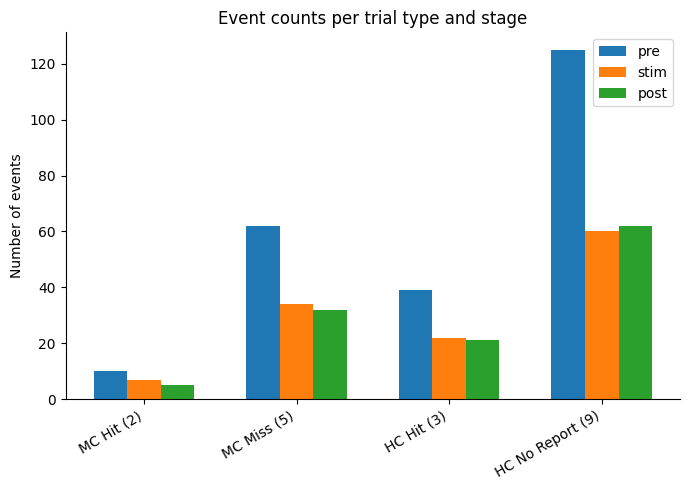

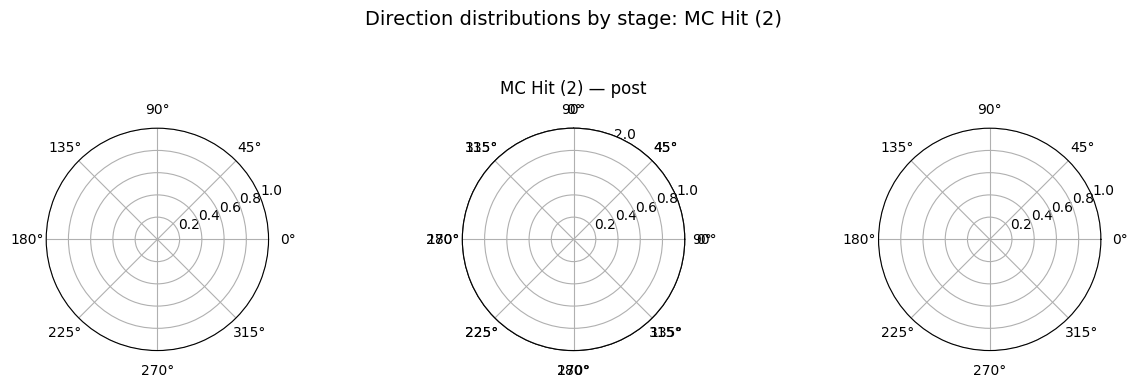

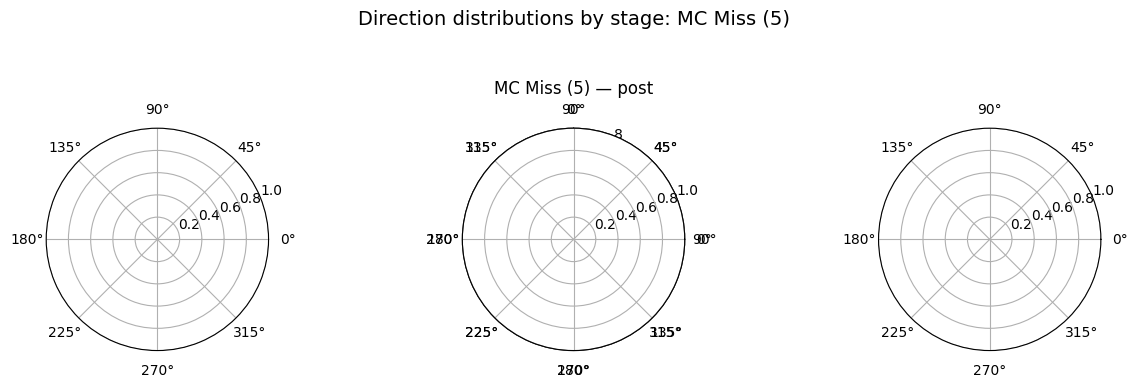

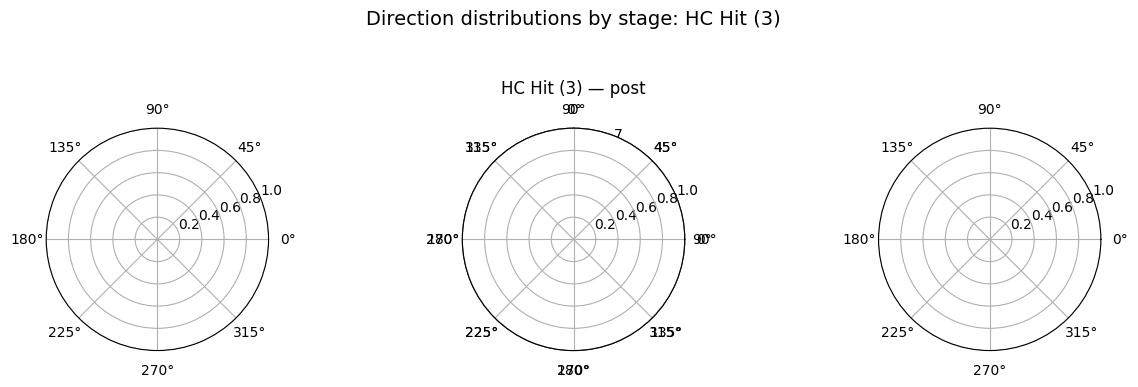

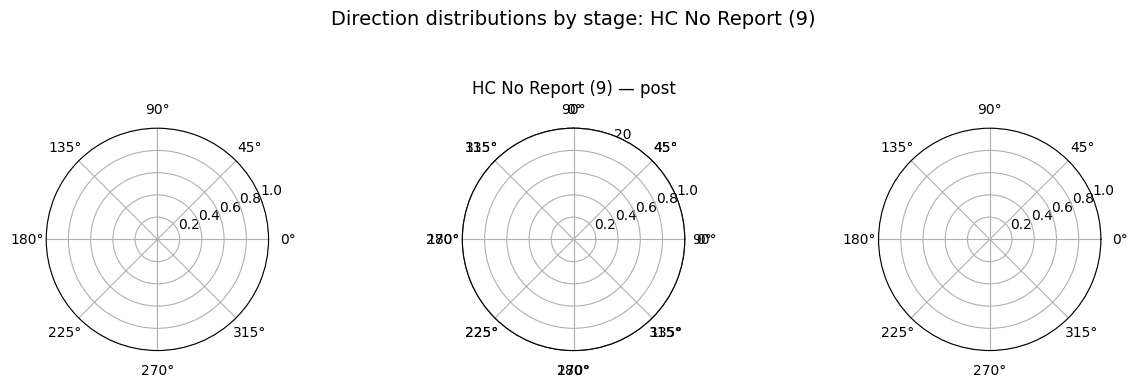

Plotting R distributions for stage: pre


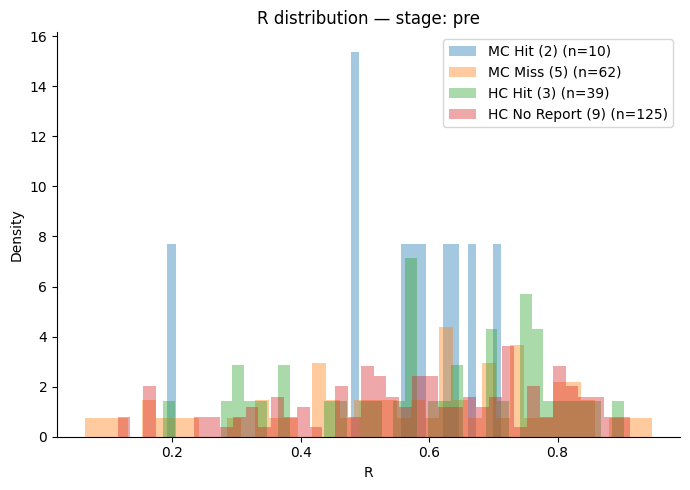

Plotting mean_freq_hz distributions for stage: pre


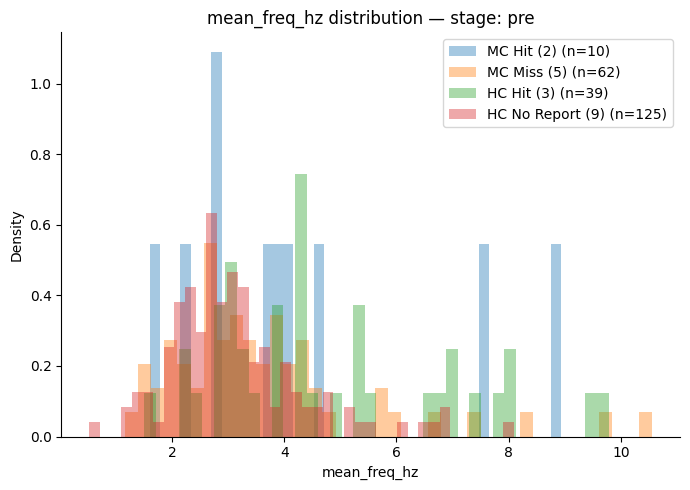

Plotting mean_lambda_px distributions for stage: pre


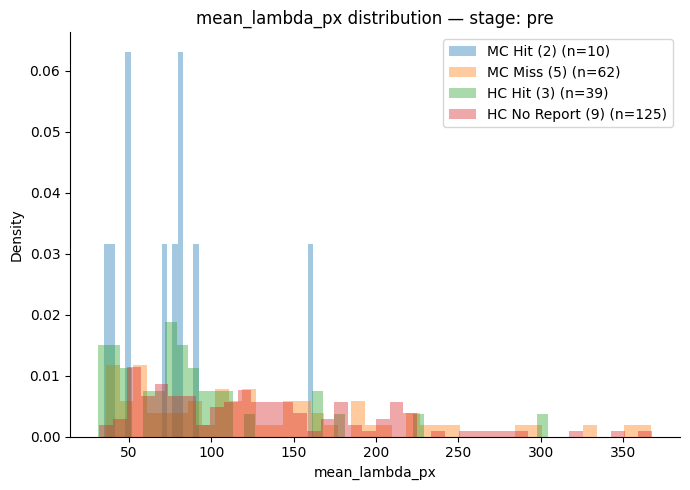

Plotting R distributions for stage: stim


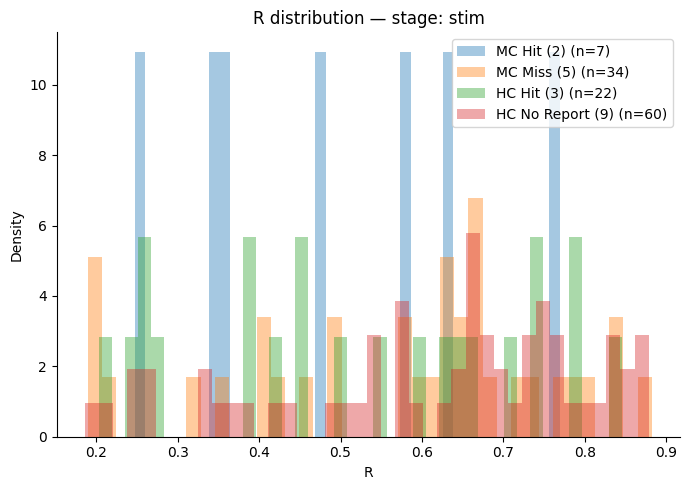

Plotting mean_freq_hz distributions for stage: stim


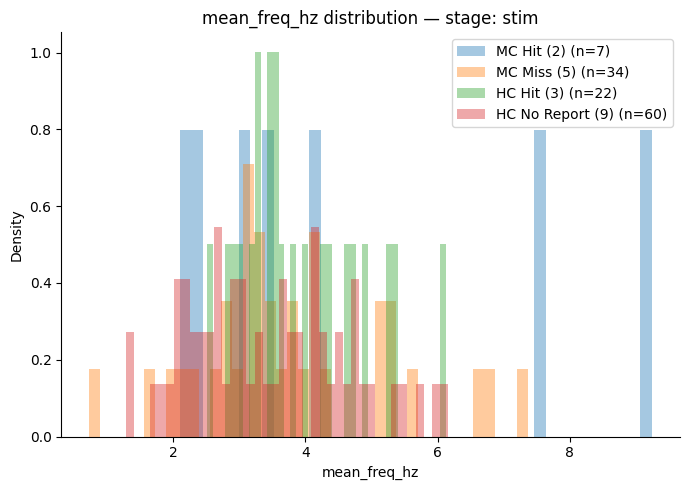

Plotting mean_lambda_px distributions for stage: stim


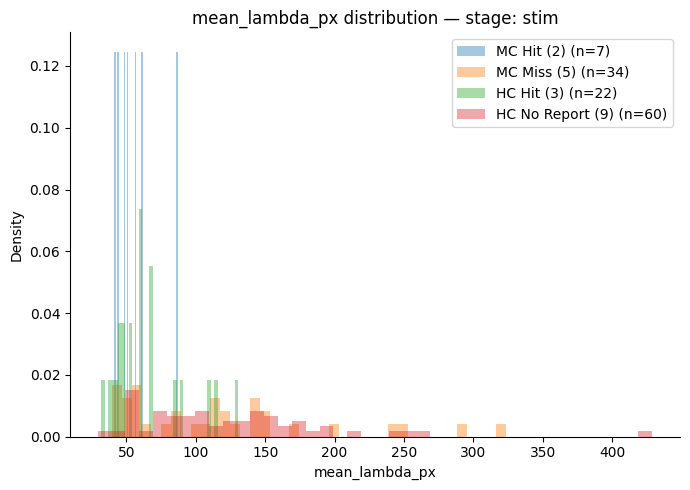

Plotting R distributions for stage: post


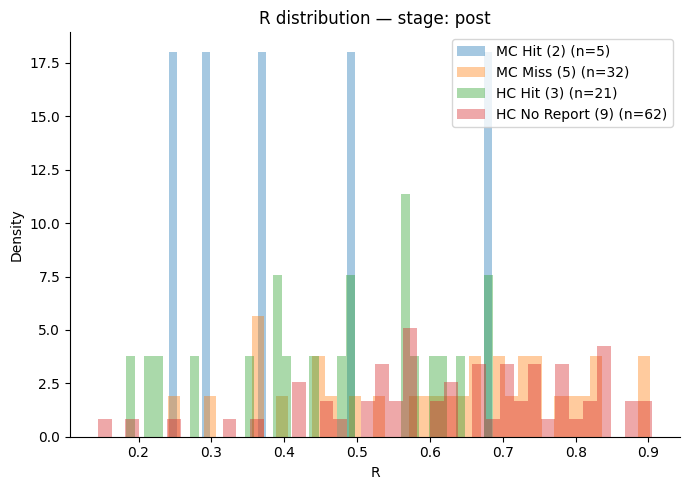

Plotting mean_freq_hz distributions for stage: post


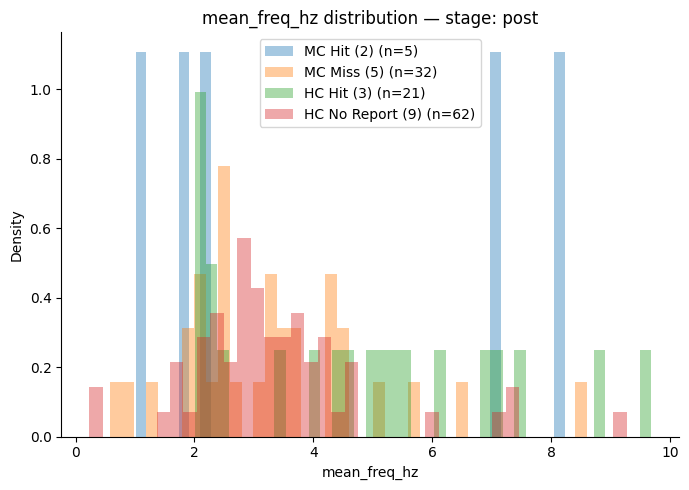

Plotting mean_lambda_px distributions for stage: post


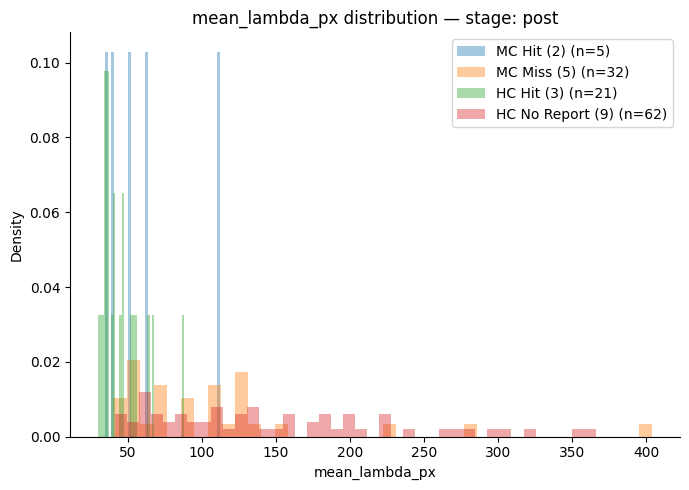

Mean ± SEM: R for stage: pre


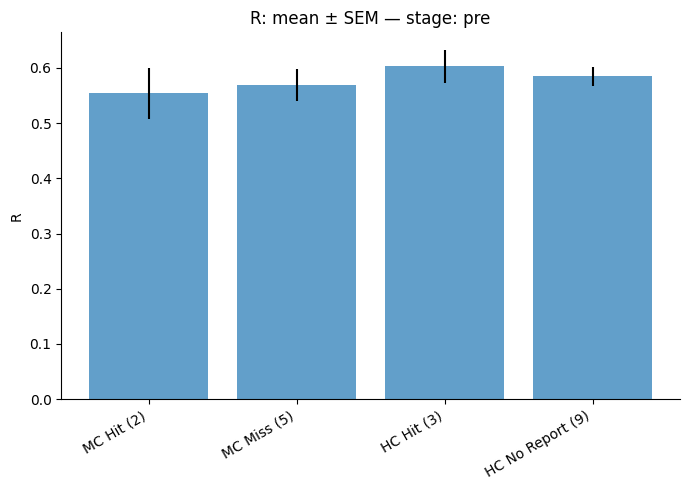

Mean ± SEM: mean_freq_hz for stage: pre


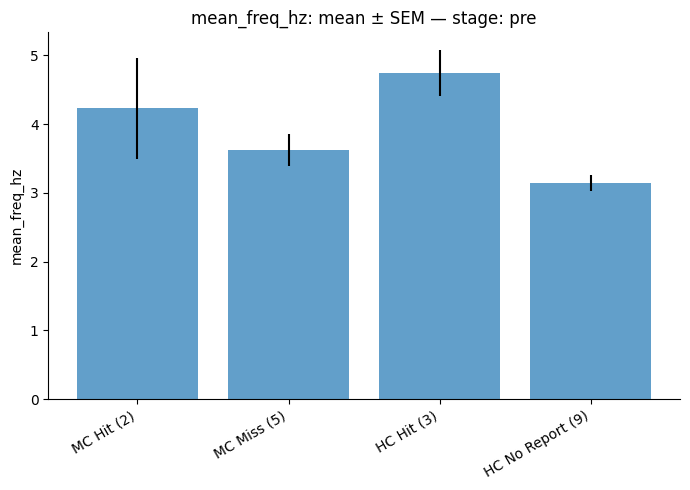

Mean ± SEM: mean_lambda_px for stage: pre


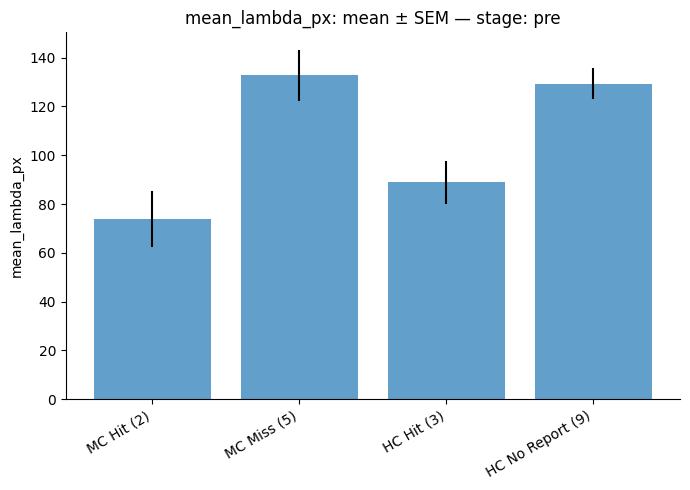

Mean ± SEM: R for stage: stim


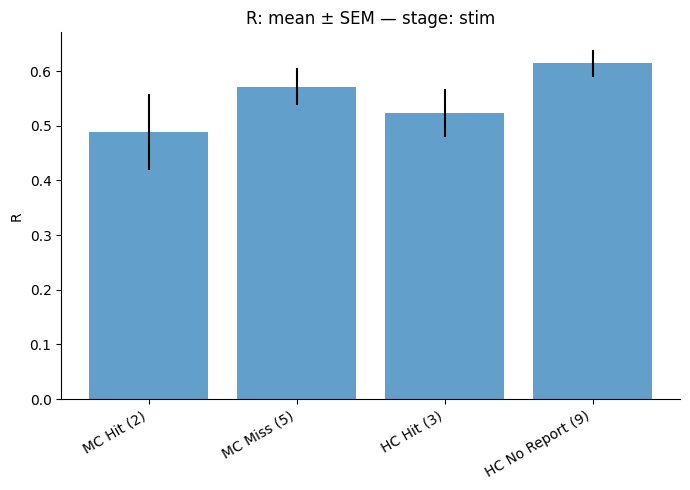

Mean ± SEM: mean_freq_hz for stage: stim


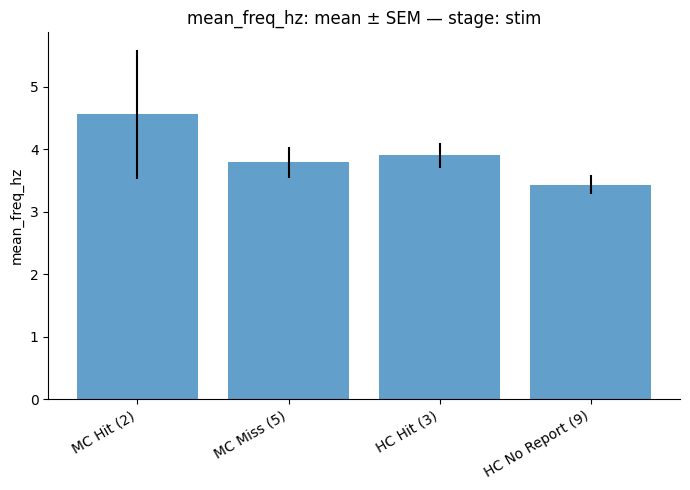

Mean ± SEM: mean_lambda_px for stage: stim


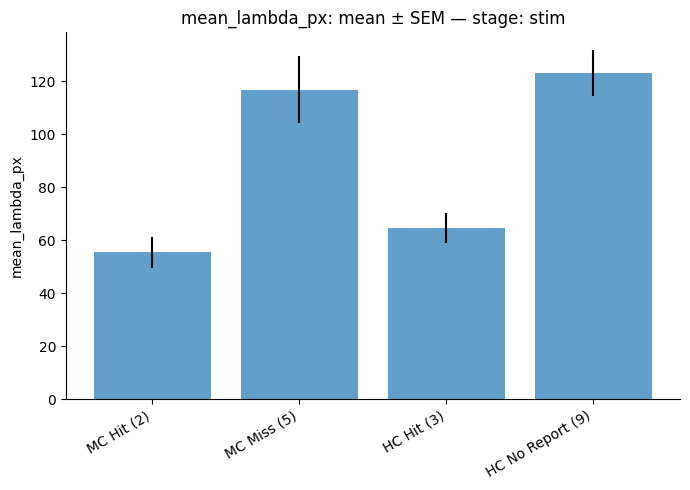

Mean ± SEM: R for stage: post


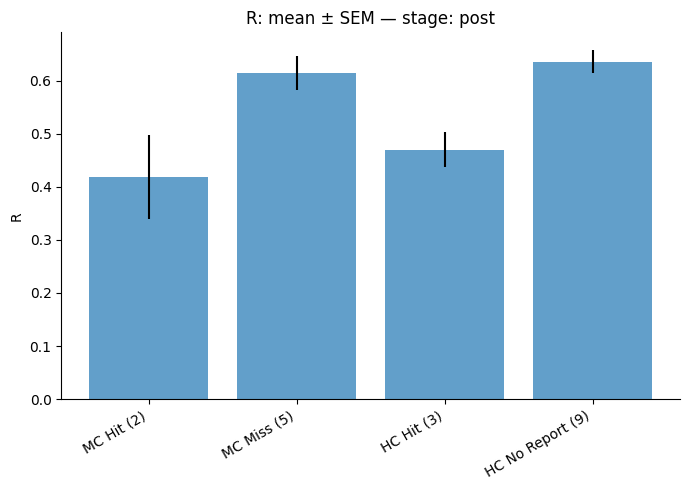

Mean ± SEM: mean_freq_hz for stage: post


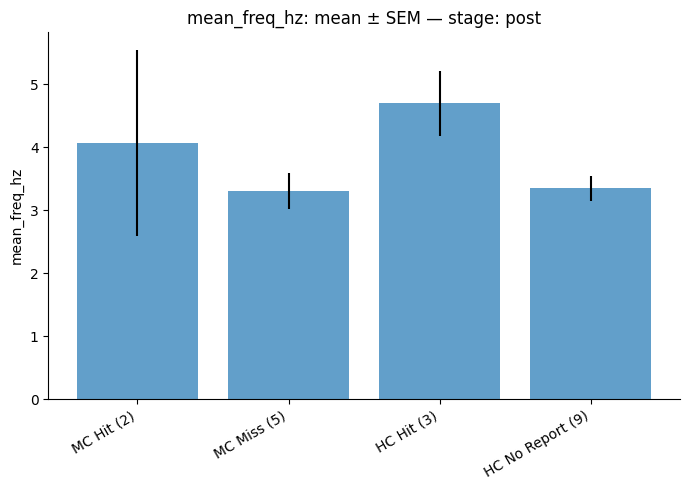

Mean ± SEM: mean_lambda_px for stage: post


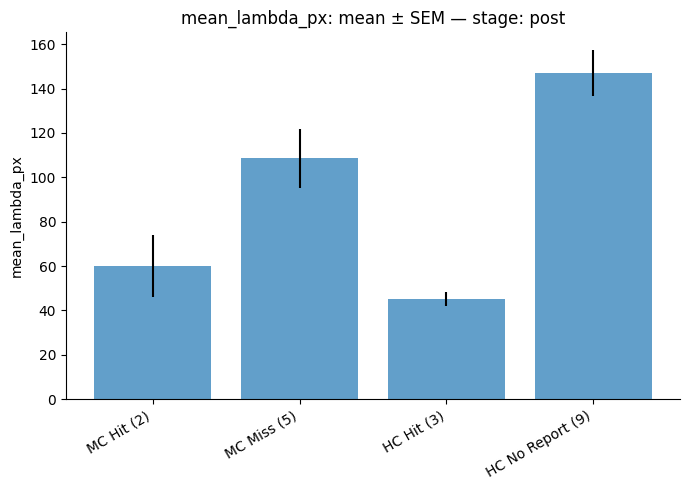

Scatter: mean_freq_hz vs R for stage: pre


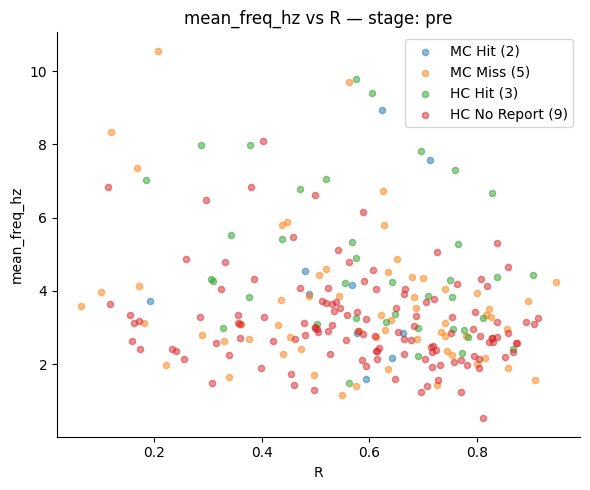

Scatter: mean_freq_hz vs R for stage: stim


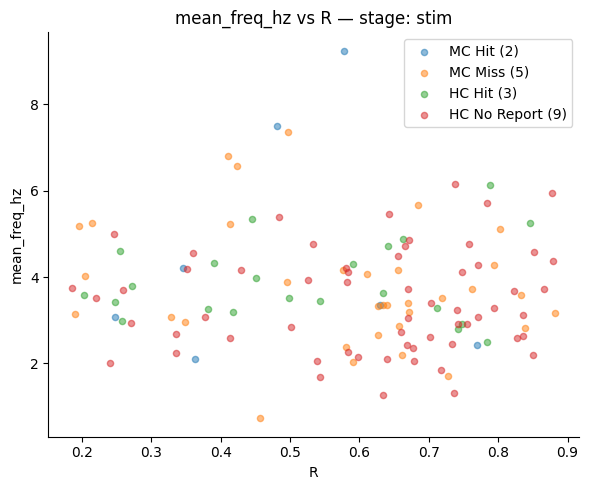

Scatter: mean_freq_hz vs R for stage: post


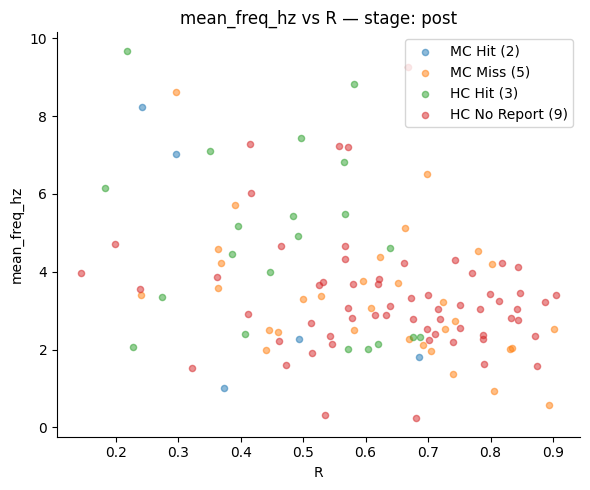

Scatter: mean_freq_hz vs mean_lambda_px for stage: pre


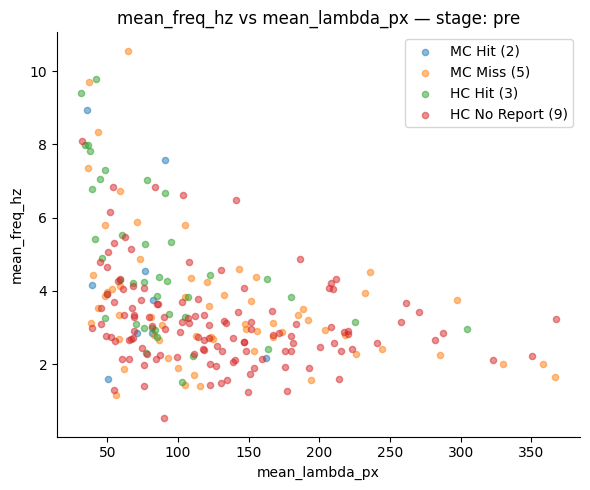

Scatter: mean_freq_hz vs mean_lambda_px for stage: stim


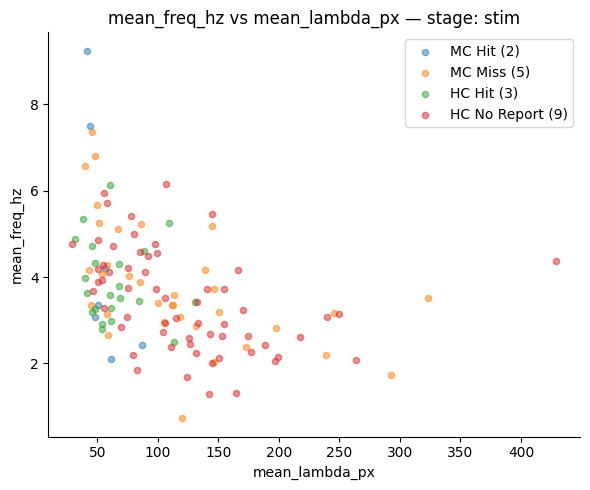

Scatter: mean_freq_hz vs mean_lambda_px for stage: post


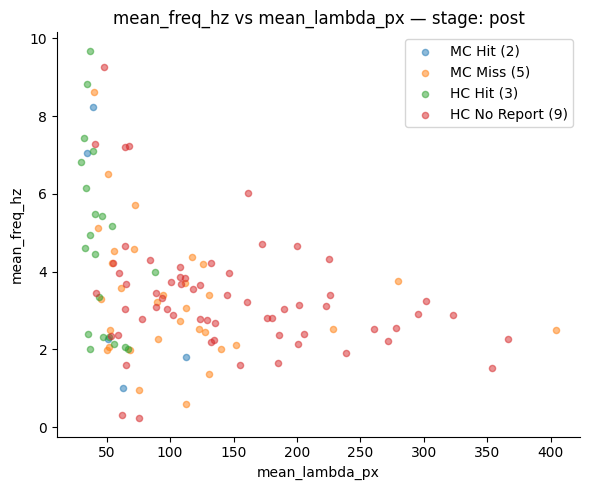

In [8]:

# 3. Filter to trial types of interest and basic cleaning
# ------------------------------------------------------------
trial_types_of_interest = [
    "MC Hit (2)",
    "MC Miss (5)",
    "HC Hit (3)",
    "HC No Report (9)",
]

# Filter
df = events[events["trial_type"].isin(trial_types_of_interest)].copy()

# Ensure stage is ordered
stage_order = ["pre", "stim", "post"]
df["stage"] = pd.Categorical(df["stage"], categories=stage_order, ordered=True)

# Optionally wrap theta to [0, 360)
df["theta_deg"] = df["theta_deg"] % 360

print("\nFiltered events:")
print(df["trial_type"].value_counts())
print("\nBy stage:")
print(df["stage"].value_counts(dropna=False))

# 4. Summary statistics
# ------------------------------------------------------------
summary_stats = (
    df.groupby(["trial_type", "stage"])
      .agg(
          n_events=("theta_deg", "count"),
          R_mean=("R", "mean"),
          R_median=("R", "median"),
          R_std=("R", "std"),
          freq_mean=("mean_freq_hz", "mean"),
          freq_median=("mean_freq_hz", "median"),
          freq_std=("mean_freq_hz", "std"),
          lam_mean=("mean_lambda_px", "mean"),
          lam_median=("mean_lambda_px", "median"),
          lam_std=("mean_lambda_px", "std"),
      )
      .reset_index()
)

print("\nSummary statistics (per trial_type x stage):")
display(summary_stats)

# 5. Helper plotting functions
# ------------------------------------------------------------
def rose_plot(df_slice, bins=24, title=""):
    """
    Polar histogram of theta_deg.
    Assumes column 'theta_deg' in degrees.
    """
    theta = np.deg2rad(df_slice["theta_deg"].values)

    ax = plt.subplot(111, projection="polar")
    ax.set_theta_zero_location("N")   # 0 deg at top
    ax.set_theta_direction(-1)        # clockwise increase

    ax.hist(theta, bins=bins)
    ax.set_title(title, fontsize=12)
    return ax


def plot_hist_by_trial_type(df, variable, stage, bins=40):
    """
    Overlaid histograms of a given variable for each trial type,
    restricted to a given stage.
    """
    plt.figure(figsize=(7, 5))
    for tt in trial_types_of_interest:
        sub = df[(df["trial_type"] == tt) & (df["stage"] == stage)]
        if len(sub) == 0:
            continue
        plt.hist(
            sub[variable],
            bins=bins,
            alpha=0.4,
            density=True,
            label=f"{tt} (n={len(sub)})",
        )

    plt.xlabel(variable)
    plt.ylabel("Density")
    plt.title(f"{variable} distribution — stage: {stage}")
    plt.legend()
    plt.tight_layout()


def bar_compare_mean_sem(df, variable, stage):
    """
    Bar plot of mean ± SEM of a variable for each trial type
    within a given stage.
    """
    sub = df[df["stage"] == stage]
    if sub.empty:
        print(f"No data for stage '{stage}' in variable '{variable}'")
        return

    summary = (
        sub.groupby("trial_type")[variable]
           .agg(["mean", "sem"])
           .reindex(trial_types_of_interest)
    )

    plt.figure(figsize=(7, 5))
    plt.bar(summary.index, summary["mean"], yerr=summary["sem"], alpha=0.7)
    plt.ylabel(variable)
    plt.xticks(rotation=30, ha="right")
    plt.title(f"{variable}: mean ± SEM — stage: {stage}")
    plt.tight_layout()


def scatter_relation(df, x, y, stage):
    """
    Scatter plot of y vs x for each trial type within a given stage.
    """
    plt.figure(figsize=(6, 5))
    for tt in trial_types_of_interest:
        sub = df[(df["trial_type"] == tt) & (df["stage"] == stage)]
        if len(sub) == 0:
            continue
        plt.scatter(sub[x], sub[y], alpha=0.5, s=20, label=tt)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x} — stage: {stage}")
    plt.legend()
    plt.tight_layout()

# 6. Event count visualization
# ------------------------------------------------------------
# Event count heatmap-like bar plot: number of events per trial_type x stage
count_table = (
    df.groupby(["trial_type", "stage"])["theta_deg"]
      .count()
      .unstack("stage")
      .reindex(trial_types_of_interest)
)

print("\nEvent counts per trial_type x stage:")
display(count_table)

plt.figure(figsize=(7, 5))
for i, stage in enumerate(stage_order):
    if stage not in count_table.columns:
        continue
    plt.bar(
        np.arange(len(trial_types_of_interest)) + i * 0.22,
        count_table[stage].values,
        width=0.22,
        label=stage,
    )

plt.xticks(
    np.arange(len(trial_types_of_interest)) + 0.22,
    trial_types_of_interest,
    rotation=30,
    ha="right",
)
plt.ylabel("Number of events")
plt.title("Event counts per trial type and stage")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Polar histograms (rose plots) of theta_deg
# ------------------------------------------------------------
# One figure per trial type, with subplots for pre/stim/post
for tt in trial_types_of_interest:
    sub_tt = df[df["trial_type"] == tt]
    if sub_tt.empty:
        continue

    plt.figure(figsize=(12, 4))
    for i, stage in enumerate(stage_order):
        sub = sub_tt[sub_tt["stage"] == stage]
        if sub.empty:
            continue
        plt.subplot(1, 3, i + 1, projection="polar")
        rose_plot(sub, bins=24, title=f"{tt} — {stage}")

    plt.suptitle(f"Direction distributions by stage: {tt}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# 8. Histograms for R, mean_freq_hz, mean_lambda_px per stage
# ------------------------------------------------------------
variables = ["R", "mean_freq_hz", "mean_lambda_px"]

for stage in stage_order:
    for var in variables:
        print(f"Plotting {var} distributions for stage: {stage}")
        plot_hist_by_trial_type(df, variable=var, stage=stage, bins=40)
        plt.show()

# 9. Mean ± SEM bar plots per stage
# ------------------------------------------------------------
for stage in stage_order:
    for var in variables:
        print(f"Mean ± SEM: {var} for stage: {stage}")
        bar_compare_mean_sem(df, variable=var, stage=stage)
        plt.show()

# 10. Example scatter relations
# ------------------------------------------------------------
# Coherence vs frequency, per stage
for stage in stage_order:
    print(f"Scatter: mean_freq_hz vs R for stage: {stage}")
    scatter_relation(df, x="R", y="mean_freq_hz", stage=stage)
    plt.show()

# Wavelength vs frequency, per stage
for stage in stage_order:
    print(f"Scatter: mean_freq_hz vs mean_lambda_px for stage: {stage}")
    scatter_relation(df, x="mean_lambda_px", y="mean_freq_hz", stage=stage)
    plt.show()

Events shape: (1056, 21)
Columns: ['event_id', 'trial_id', 't_start', 't_end', 'duration_s', 'stage', 'theta_deg', 'R', 'n_frames', 'mean_amp', 'mean_freq_hz', 'mean_k_rad_per_px', 'mean_lambda_px', 'mean_speed_px_s', 'iqr_amp', 'iqr_freq_hz', 'iqr_k_rad_per_px', 'iqr_lambda_px', 'iqr_speed_px_s', 'n_valid_frames', 'trial_type']

                               event_id                            trial_id  \
0  cfm002mjr/20240517/meas00/trial001/1  cfm002mjr/20240517/meas00/trial001   
1  cfm002mjr/20240517/meas00/trial001/2  cfm002mjr/20240517/meas00/trial001   
2  cfm002mjr/20240517/meas00/trial001/3  cfm002mjr/20240517/meas00/trial001   
3  cfm002mjr/20240517/meas00/trial001/4  cfm002mjr/20240517/meas00/trial001   
4  cfm002mjr/20240517/meas00/trial001/5  cfm002mjr/20240517/meas00/trial001   

    t_start     t_end  duration_s stage   theta_deg         R  n_frames  \
0  0.000000  0.273566    0.273566   pre  156.793832  0.691033        43   
1  0.458064  0.559856    0.101792   pre   2

C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])


,trial_type,stage,n_events,R_mean,R_median,R_std,freq_mean,freq_median,freq_std,lam_mean,lam_median,lam_std
0,HC Hit (3),pre,39,0.603128,0.630208,0.186043,4.748467,4.277118,2.080524,88.938854,77.768972,55.196493
1,HC Hit (3),stim,22,0.523352,0.520969,0.203620,3.903546,3.608455,0.936195,64.546516,60.548697,26.052584
2,HC Hit (3),post,21,0.470049,0.491860,0.154233,4.698575,4.609539,2.343447,45.252121,40.548993,14.305982
3,HC No Report (9),pre,125,0.584574,0.594239,0.201279,3.145679,2.909248,1.246143,129.388990,118.553518,69.402207
4,HC No Report (9),stim,60,0.614254,0.667255,0.190317,3.433815,3.252817,1.181652,123.145839,108.613691,67.535187
5,HC No Report (9),post,62,0.635895,0.663928,0.174498,3.351444,3.099362,1.551607,147.044901,130.635555,82.020551
6,MC Hit (2),pre,10,0.553795,0.585354,0.146050,4.230871,3.821791,2.328954,73.904558,73.929565,36.520127
7,MC Hit (2),stim,7,0.487910,0.481490,0.183064,4.558203,3.354530,2.738835,55.400463,50.411176,15.524415
8,MC Hit (2),post,5,0.418289,0.373226,0.176916,4.069873,2.259090,3.311830,59.942998,50.905133,31.243940
9,MC Miss (5),pre,62,0.568994,0.623517,0.222577,3.622751,3.168134,1.852785,132.839072,113.963082,81.887134



Event counts per trial_type x stage:


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:194: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])["R"]


stage,pre,stim,post
trial_type,,,
MC Hit (2),10,7,5
MC Miss (5),62,34,32
HC Hit (3),39,22,21
HC No Report (9),125,60,62


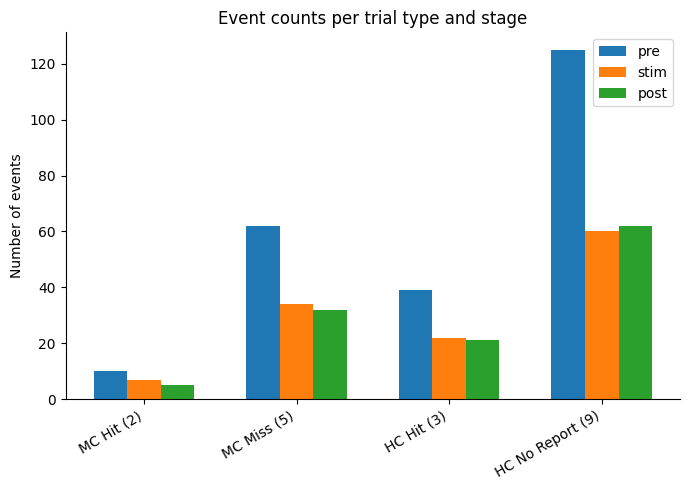

Plotting R distributions for stage: pre


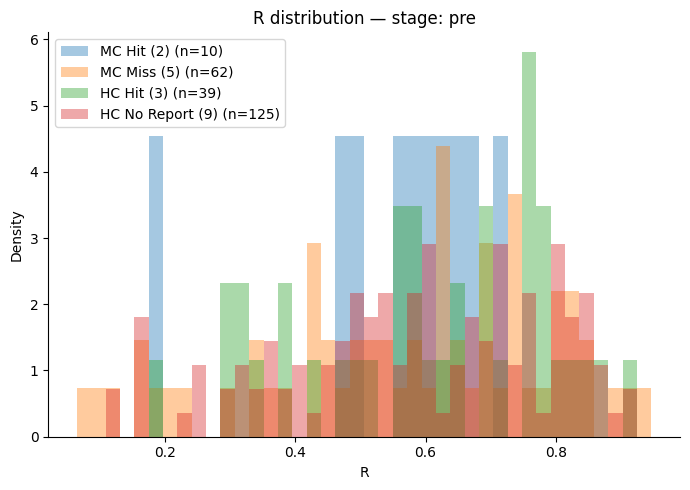

Plotting mean_freq_hz distributions for stage: pre


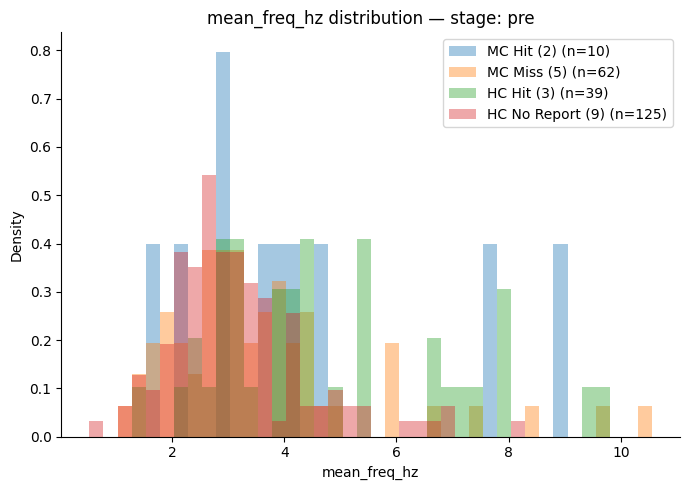

Plotting mean_lambda_px distributions for stage: pre


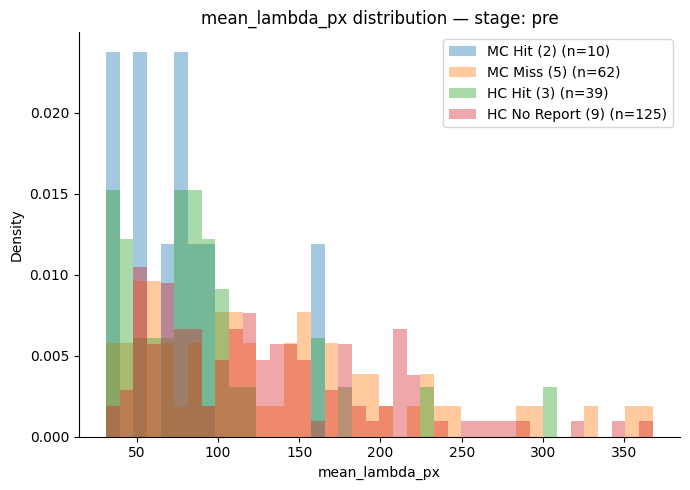

Plotting R distributions for stage: stim


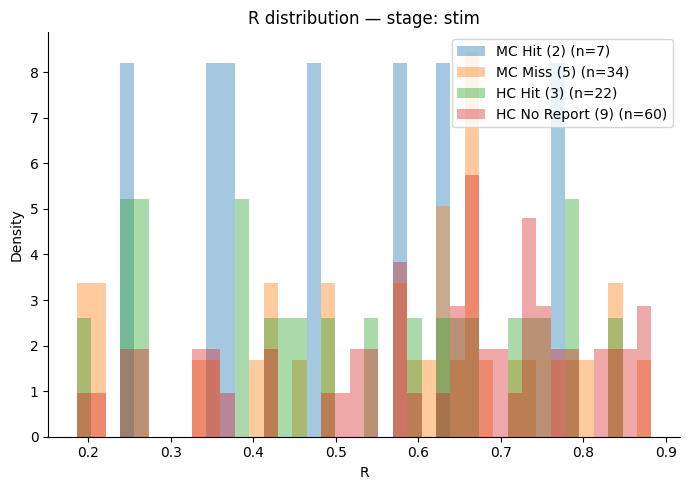

Plotting mean_freq_hz distributions for stage: stim


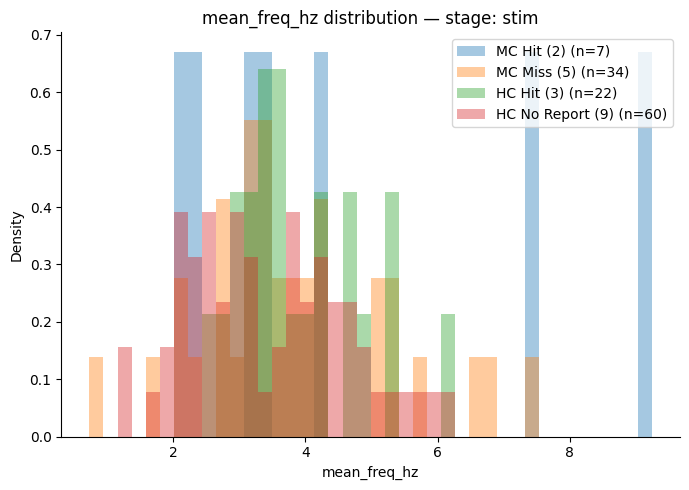

Plotting mean_lambda_px distributions for stage: stim


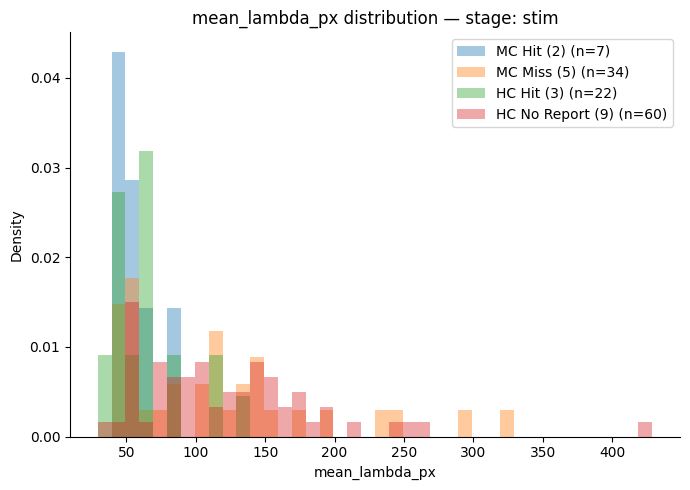

Plotting R distributions for stage: post


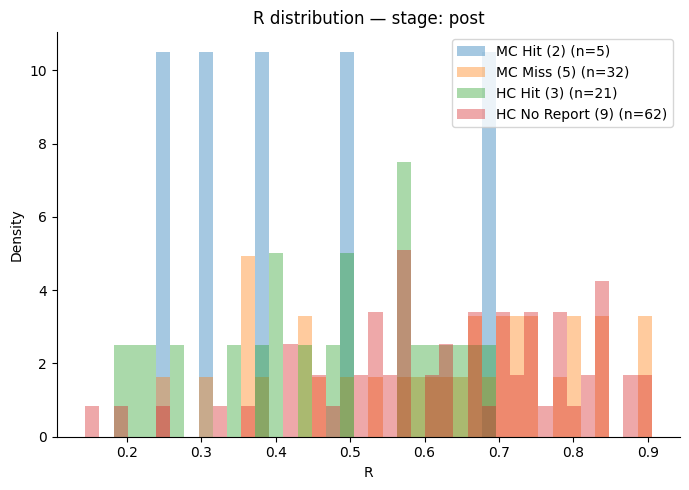

Plotting mean_freq_hz distributions for stage: post


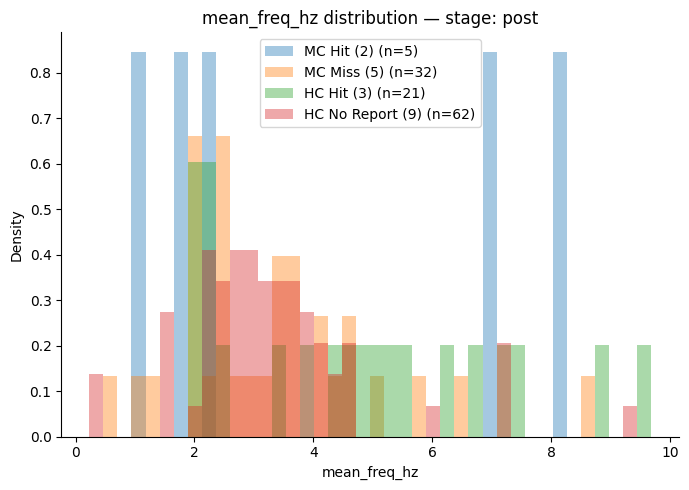

Plotting mean_lambda_px distributions for stage: post


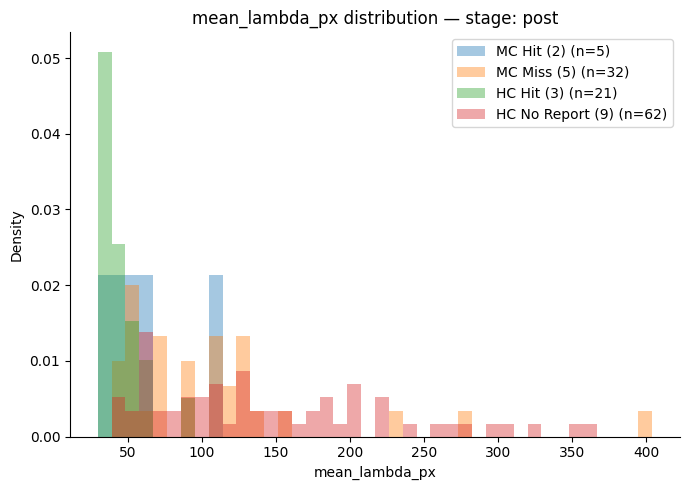


R summary by stage (all trial types pooled):


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:238: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("stage")["R"]


,count,mean,median,std,sem
stage,,,,,
pre,236,0.582243,0.608412,0.202006,0.013149
stim,123,0.578972,0.633352,0.195433,0.017622
post,120,0.592191,0.612423,0.185187,0.016905


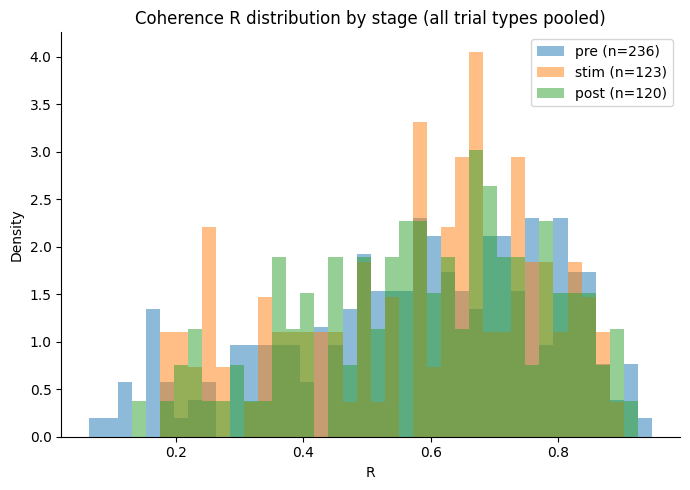

C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:184: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=stage_order, showfliers=True)


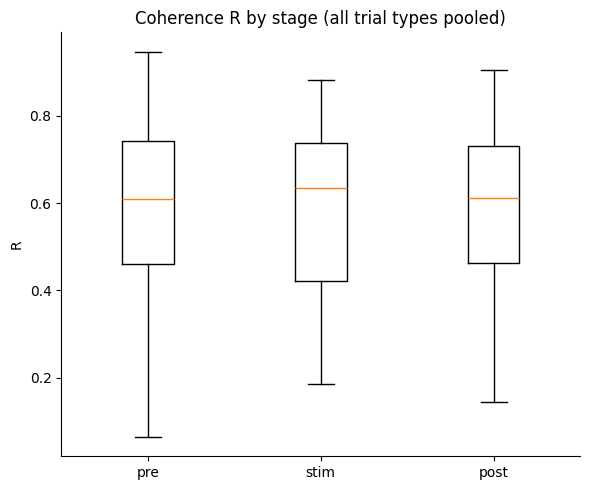

C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])[variable]


Mean ± SEM of R by trial type and stage


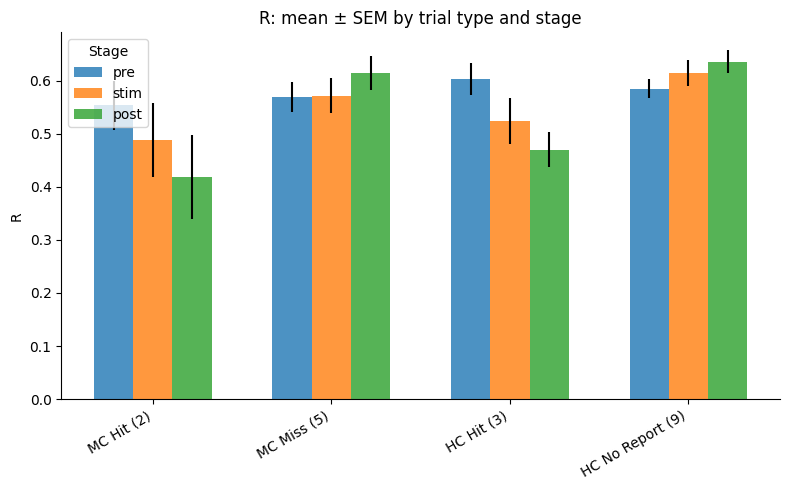

Mean ± SEM of mean_freq_hz by trial type and stage


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])[variable]


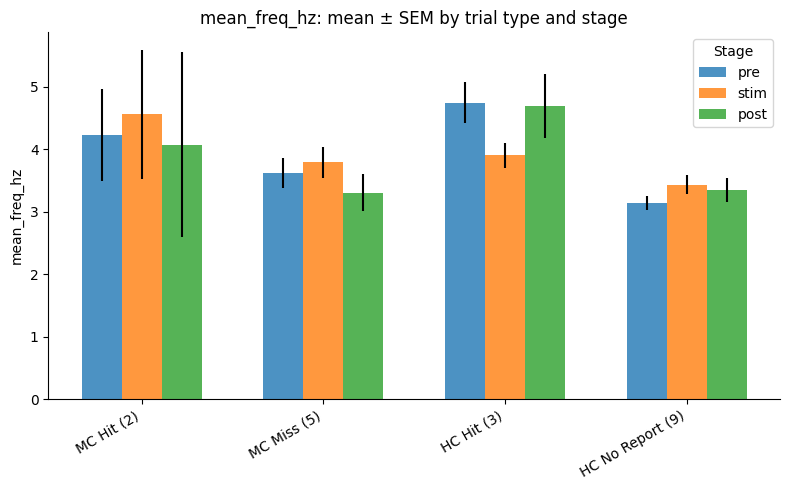

Mean ± SEM of mean_lambda_px by trial type and stage


C:\Users\Katie\AppData\Local\Temp\ipykernel_28756\946612916.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["trial_type", "stage"])[variable]


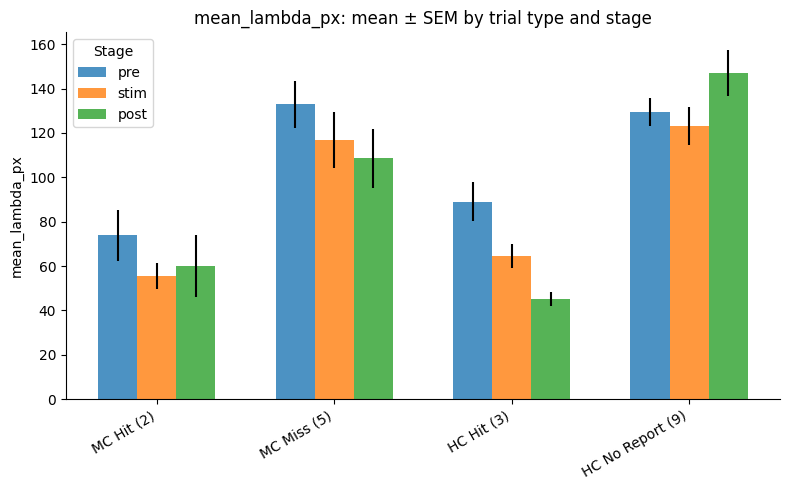

In [9]:
# ============================================================
# Wave Events Analysis Notebook (Updated)
# ============================================================

# 1. Imports and basic setup
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 2. Load data
# ------------------------------------------------------------
events = pd.read_csv("events_df_cfm002_240517.csv")

print("Events shape:", events.shape)
print("Columns:", events.columns.tolist())
print()
print(events.head())

# 3. Filter to trial types of interest and basic cleaning
# ------------------------------------------------------------
trial_types_of_interest = [
    "MC Hit (2)",
    "MC Miss (5)",
    "HC Hit (3)",
    "HC No Report (9)",
]

df = events[events["trial_type"].isin(trial_types_of_interest)].copy()

stage_order = ["pre", "stim", "post"]
df["stage"] = pd.Categorical(df["stage"], categories=stage_order, ordered=True)

# Wrap theta (if present) to [0, 360), just for consistency
if "theta_deg" in df.columns:
    df["theta_deg"] = df["theta_deg"] % 360

print("\nFiltered events (trial_type counts):")
print(df["trial_type"].value_counts())
print("\nBy stage:")
print(df["stage"].value_counts(dropna=False))

# 4. Summary statistics per trial_type x stage
# ------------------------------------------------------------
summary_stats = (
    df.groupby(["trial_type", "stage"])
      .agg(
          n_events=("R", "count"),
          R_mean=("R", "mean"),
          R_median=("R", "median"),
          R_std=("R", "std"),
          freq_mean=("mean_freq_hz", "mean"),
          freq_median=("mean_freq_hz", "median"),
          freq_std=("mean_freq_hz", "std"),
          lam_mean=("mean_lambda_px", "mean"),
          lam_median=("mean_lambda_px", "median"),
          lam_std=("mean_lambda_px", "std"),
      )
      .reset_index()
)

print("\nSummary statistics (per trial_type x stage):")
display(summary_stats)

# 5. Helper plotting functions
# ------------------------------------------------------------
def plot_hist_by_trial_type(df, variable, stage, bins=40):
    """
    Overlaid histograms of a given variable for each trial type,
    restricted to a given stage, with shared bin edges.
    """
    df_stage = df[df["stage"] == stage]
    data_all = df_stage[variable].dropna()

    if data_all.empty:
        print(f"No data for variable '{variable}' at stage '{stage}'")
        return

    # Common bin edges for all trial types at this stage
    bin_edges = np.histogram_bin_edges(data_all, bins=bins)

    plt.figure(figsize=(7, 5))
    for tt in trial_types_of_interest:
        sub = df_stage[df_stage["trial_type"] == tt]
        if len(sub) == 0:
            continue
        plt.hist(
            sub[variable],
            bins=bin_edges,
            alpha=0.4,
            density=True,
            label=f"{tt} (n={len(sub)})",
        )

    plt.xlabel(variable)
    plt.ylabel("Density")
    plt.title(f"{variable} distribution — stage: {stage}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def bar_compare_mean_sem_all_stages(df, variable):
    """
    Grouped bar plot: mean ± SEM of `variable` for each trial type,
    with bars for each stage (pre / stim / post) on the same figure.
    """
    summary = (
        df.groupby(["trial_type", "stage"])[variable]
          .agg(["mean", "sem"])
          .reindex(trial_types_of_interest, level="trial_type")
          .loc[pd.IndexSlice[:, stage_order], :]
    )

    # Reshape to table: rows = trial_type, columns = MultiIndex(stage, stat)
    summary_unstack = summary.unstack("stage")  # columns like ('mean','pre'), ('sem','pre'), ...

    x = np.arange(len(trial_types_of_interest))
    width = 0.22

    plt.figure(figsize=(8, 5))

    for i, st in enumerate(stage_order):
        if ("mean", st) not in summary_unstack.columns:
            continue
        means = summary_unstack[("mean", st)]
        sems = summary_unstack[("sem", st)]
        plt.bar(
            x + i * width,
            means,
            yerr=sems,
            width=width,
            alpha=0.8,
            label=st,
        )

    plt.xticks(x + width, trial_types_of_interest, rotation=30, ha="right")
    plt.ylabel(variable)
    plt.title(f"{variable}: mean ± SEM by trial type and stage")
    plt.legend(title="Stage")
    plt.tight_layout()
    plt.show()


def plot_R_by_stage_pooled(df, bins=40):
    """
    Compare coherence R between stages, pooling all trial types.
    Produces overlaid histograms and a boxplot.
    """
    # Histogram with shared bin edges
    data_all = df["R"].dropna()
    if data_all.empty:
        print("No R data available")
        return

    bin_edges = np.histogram_bin_edges(data_all, bins=bins)

    plt.figure(figsize=(7, 5))
    for st in stage_order:
        sub = df[df["stage"] == st]["R"].dropna()
        if len(sub) == 0:
            continue
        plt.hist(
            sub,
            bins=bin_edges,
            alpha=0.5,
            density=True,
            label=f"{st} (n={len(sub)})",
        )
    plt.xlabel("R")
    plt.ylabel("Density")
    plt.title("Coherence R distribution by stage (all trial types pooled)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(6, 5))
    data = [df[df["stage"] == st]["R"].dropna() for st in stage_order]
    plt.boxplot(data, labels=stage_order, showfliers=True)
    plt.ylabel("R")
    plt.title("Coherence R by stage (all trial types pooled)")
    plt.tight_layout()
    plt.show()


# 6. Event count visualization
# ------------------------------------------------------------
count_table = (
    df.groupby(["trial_type", "stage"])["R"]
      .count()
      .unstack("stage")
      .reindex(trial_types_of_interest)
)

print("\nEvent counts per trial_type x stage:")
display(count_table)

plt.figure(figsize=(7, 5))
for i, stage in enumerate(stage_order):
    if stage not in count_table.columns:
        continue
    plt.bar(
        np.arange(len(trial_types_of_interest)) + i * 0.22,
        count_table[stage].values,
        width=0.22,
        label=stage,
    )

plt.xticks(
    np.arange(len(trial_types_of_interest)) + 0.22,
    trial_types_of_interest,
    rotation=30,
    ha="right",
)
plt.ylabel("Number of events")
plt.title("Event counts per trial type and stage")
plt.legend()
plt.tight_layout()
plt.show()

# 7. Histograms for R, mean_freq_hz, mean_lambda_px per stage (by trial type)
# ------------------------------------------------------------
variables = ["R", "mean_freq_hz", "mean_lambda_px"]

for stage in stage_order:
    for var in variables:
        print(f"Plotting {var} distributions for stage: {stage}")
        plot_hist_by_trial_type(df, variable=var, stage=stage, bins=40)

# 8. Coherence R: pooled comparison across stages
# ------------------------------------------------------------
R_stage_stats = (
    df.groupby("stage")["R"]
      .agg(["count", "mean", "median", "std", "sem"])
      .loc[stage_order]
)

print("\nR summary by stage (all trial types pooled):")
display(R_stage_stats)

plot_R_by_stage_pooled(df, bins=40)

# 9. Mean ± SEM grouped bar plots for all variables
# ------------------------------------------------------------
for var in variables:
    print(f"Mean ± SEM of {var} by trial type and stage")
    bar_compare_mean_sem_all_stages(df, variable=var)

# ============================================================
# End of notebook
# ============================================================